In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
import pandas as pd

folder = r"C:\Users\oorko\OneDrive\Documents\projects\Sales_Forecasting\data\raw"

train = pd.read_csv(folder + r"\train.csv", parse_dates=["date"])
test = pd.read_csv(folder + r"\test.csv", parse_dates=["date"])
stores = pd.read_csv(folder + r"\stores.csv")
oil = pd.read_csv(folder + r"\oil.csv", parse_dates=["date"])
holidays = pd.read_csv(folder + r"\holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(folder + r"\transactions.csv", parse_dates=["date"])

print("All files loaded successfully")

All files loaded successfully


In [3]:
# Check each dataset
for name, df in [('Train', train), ('Test', test), ('Stores', stores), 
                  ('Oil', oil), ('Holidays', holidays), ('Transactions', transactions)]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.dtypes)
    print(df.head(3))


Train: 3000888 rows, 6 columns
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0

Test: 28512 rows, 5 columns
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
onpromotion             int64
dtype: object
        id       date  store_nbr      family  onpromotion
0  3000888 2017-08-16          1  AUTOMOTIVE            0
1  3000889 2017-08-16          1   BABY CARE            0
2  3000890 2017-08-16          1      BEAUTY            2

Stores: 54 rows, 5 columns
store_nbr    int64
city           str
state          str
type           str
clust

In [4]:
print("=== MISSING VALUES ===\n")
for name, df in [('Train', train), ('Test', test), ('Stores', stores), 
                  ('Oil', oil), ('Holidays', holidays), ('Transactions', transactions)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        print(nulls)
    else:
        print(f"\n{name}: No missing values")

=== MISSING VALUES ===


Train: No missing values

Test: No missing values

Stores: No missing values

Oil:
dcoilwtico    43
dtype: int64

Holidays: No missing values

Transactions: No missing values


In [5]:
print("=== DUPLICATE ROWS ===\n")
for name, df in [('Train', train), ('Stores', stores), ('Oil', oil), 
                  ('Holidays', holidays), ('Transactions', transactions)]:
    dupes = df.duplicated().sum()
    print(f"{name}: {dupes} duplicate rows")

=== DUPLICATE ROWS ===

Train: 0 duplicate rows
Stores: 0 duplicate rows
Oil: 0 duplicate rows
Holidays: 0 duplicate rows
Transactions: 0 duplicate rows


In [6]:
print(train.info())
print("\n--- Basic Stats ---")
print(train.describe())

print(f"\nDate range: {train['date'].min()} to {train['date'].max()}")
print(f"Unique stores: {train['store_nbr'].nunique()}")
print(f"Unique product families: {train['family'].nunique()}")
print(f"\nProduct families:\n{train['family'].unique()}")

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 168.2 MB
None

--- Basic Stats ---
                 id                        date     store_nbr         sales  \
count  3.000888e+06                     3000888  3.000888e+06  3.000888e+06   
mean   1.500444e+06  2015-04-24 08:27:04.703088  2.750000e+01  3.577757e+02   
min    0.000000e+00         2013-01-01 00:00:00  1.000000e+00  0.000000e+00   
25%    7.502218e+05         2014-02-26 18:00:00  1.400000e+01  0.000000e+00   
50%    1.500444e+06         2015-04-24 12:00:00  2.750000e+01  1.100000e+01   
75%    2.250665e+06         2016-06-19 06:00:00  4.10000

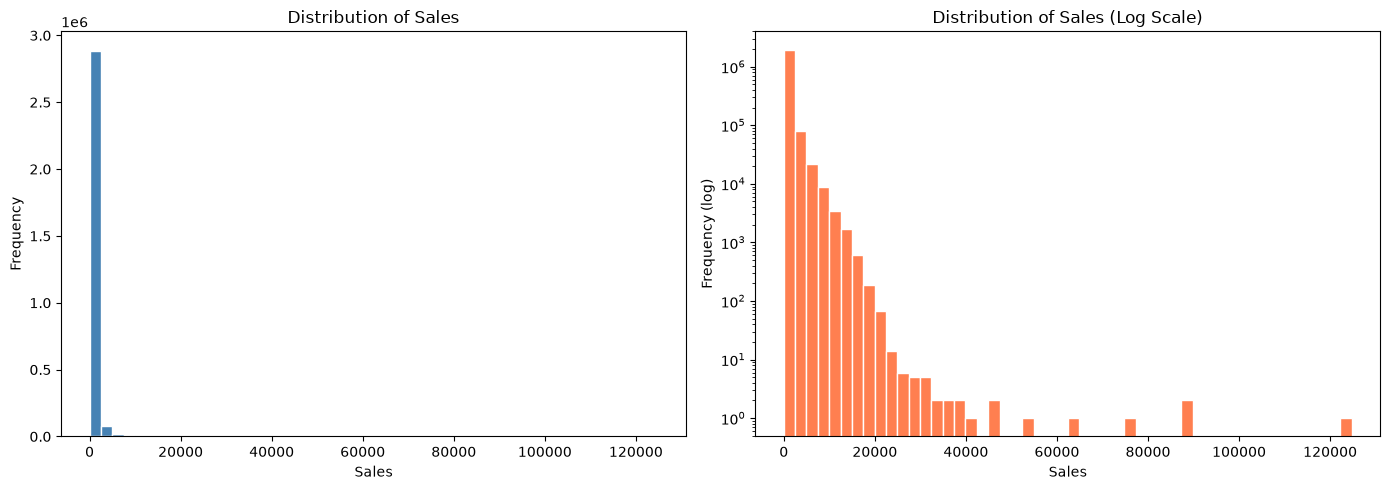

% of rows with zero sales: 31.3%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of all sales
axes[0].hist(train['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Right: log scale (better for skewed data)
axes[1].hist(train['sales'][train['sales'] > 0], bins=50, color='coral', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Sales (Log Scale)')
axes[1].set_xlabel('Sales')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

print(f"% of rows with zero sales: {(train['sales'] == 0).mean() * 100:.1f}%")

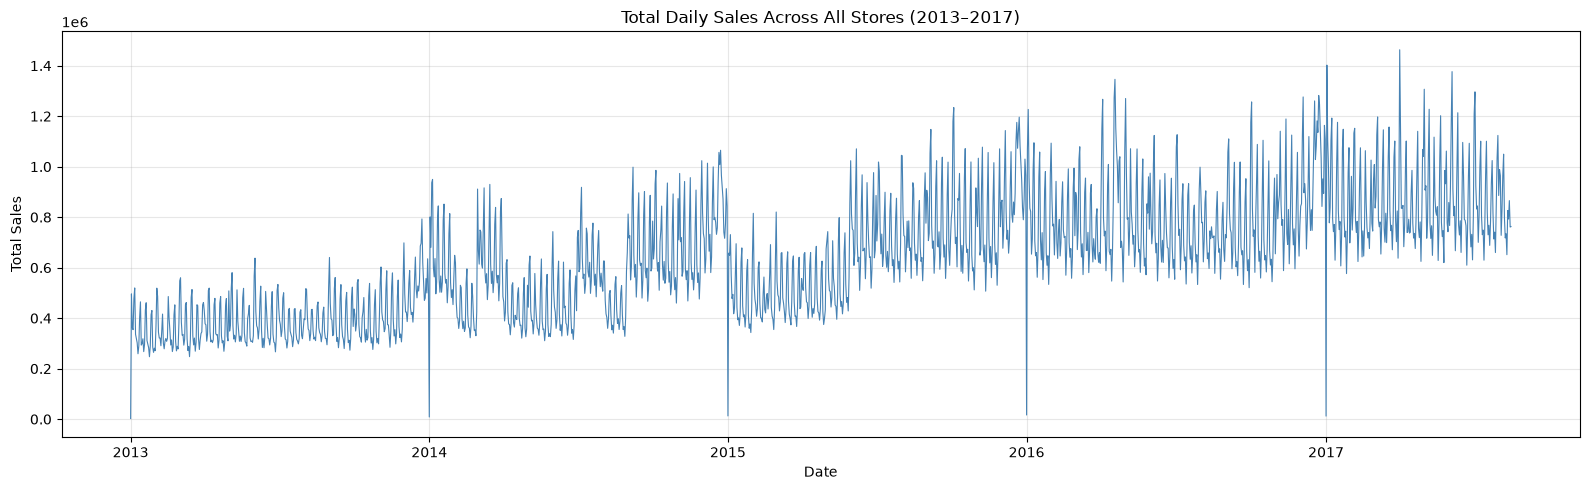

In [8]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Sales Across All Stores (2013–2017)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

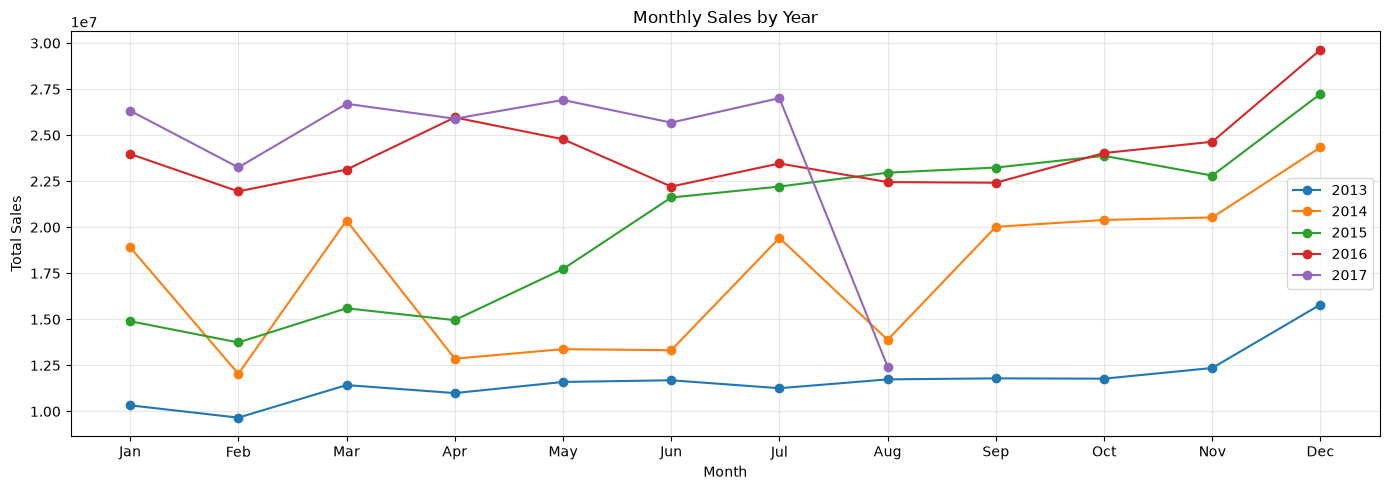

In [9]:
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['dayofweek'] = train['date'].dt.dayofweek  # 0=Monday, 6=Sunday

monthly_sales = train.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
for year in monthly_sales['year'].unique():
    subset = monthly_sales[monthly_sales['year'] == year]
    plt.plot(subset['month'], subset['sales'], marker='o', label=str(year))

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

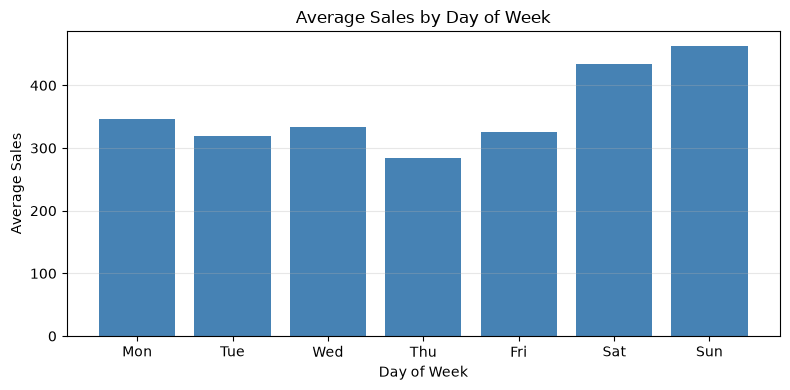

In [10]:
dow_sales = train.groupby('dayofweek')['sales'].mean().reset_index()

plt.figure(figsize=(8, 4))
bars = plt.bar(dow_sales['dayofweek'], dow_sales['sales'], color='steelblue')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

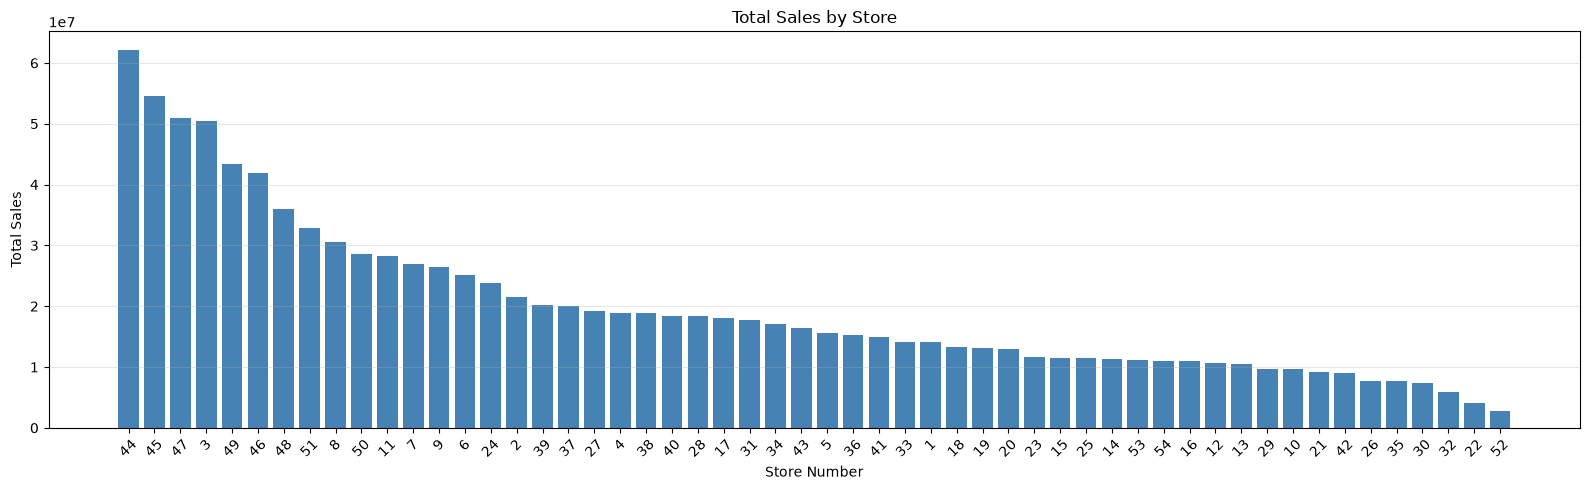

Top 5 stores by sales:
   store_nbr         sales
0         44  6.208755e+07
1         45  5.449801e+07
2         47  5.094831e+07
3          3  5.048191e+07
4         49  4.342010e+07


In [11]:
store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(16, 5))
plt.bar(store_sales['store_nbr'].astype(str), store_sales['sales'], color='steelblue')
plt.title('Total Sales by Store')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Top 5 stores by sales:")
print(store_sales.head())

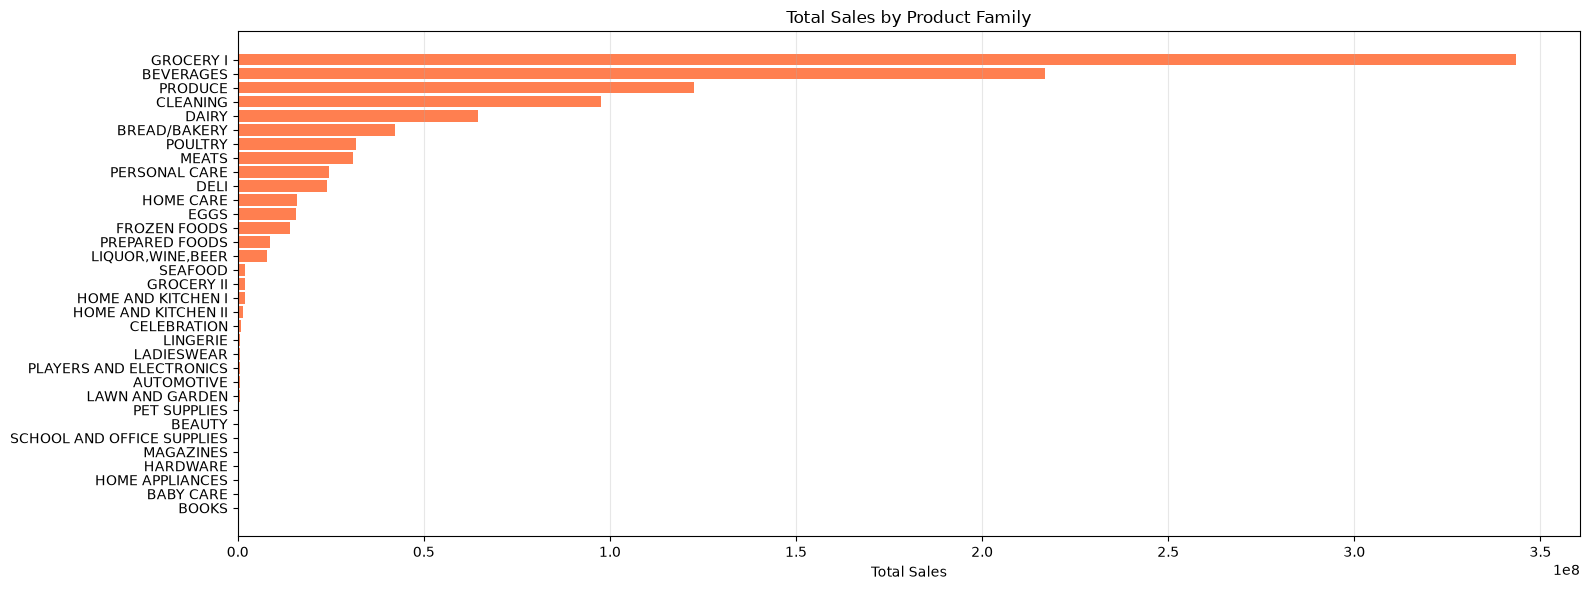

In [12]:
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(16, 6))
plt.barh(family_sales['family'], family_sales['sales'], color='coral')
plt.title('Total Sales by Product Family')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
5          6          Quito                       Pichincha    D       13
6          7          Quito                       Pichincha    D        8
7          8          Quito                       Pichincha    D        8
8          9          Quito                       Pichincha    B        6
9         10          Quito                       Pichincha    C       15

Store types: <ArrowStringArray>
['D', 'B', 'C', 'E', 'A']
Length: 5, dtype: str
Number of clusters: 17

Stores per type:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype:

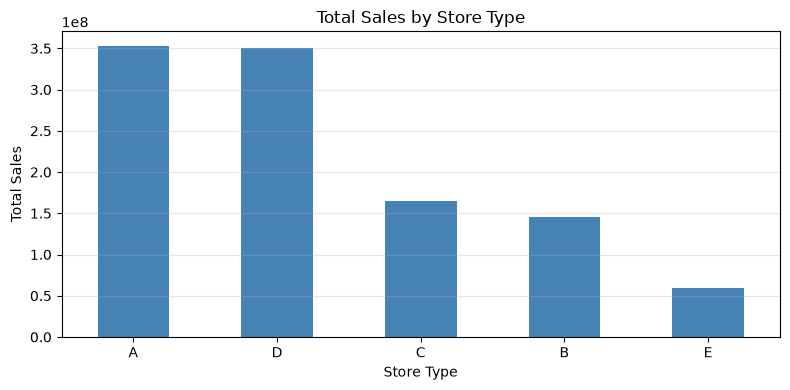

In [13]:
print(stores.head(10))
print("\nStore types:", stores['type'].unique())
print("Number of clusters:", stores['cluster'].nunique())

# Stores by type
print("\nStores per type:")
print(stores['type'].value_counts())

# Merge store metadata with sales to see sales by type
train_stores = train.merge(stores, on='store_nbr')
type_sales = train_stores.groupby('type')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
type_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

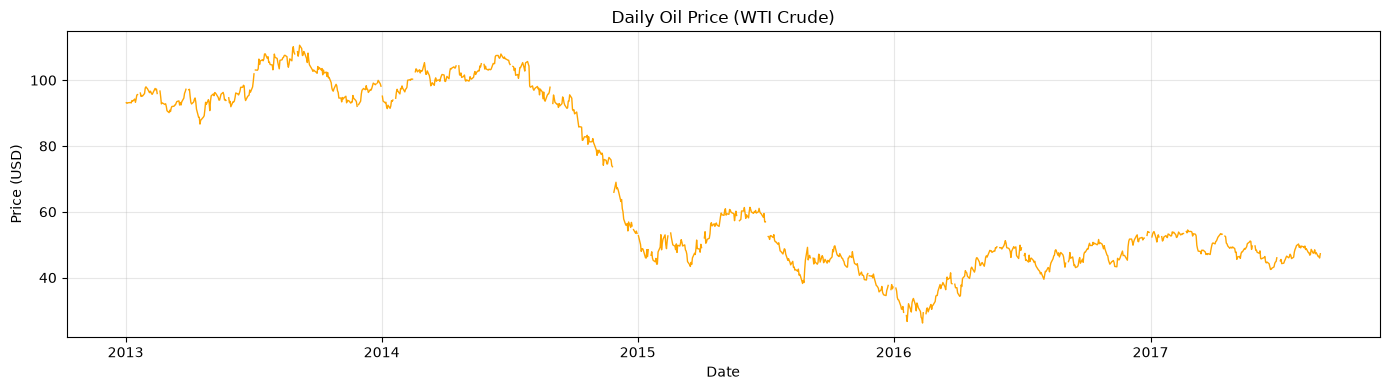

Missing oil prices: 43 days
Date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00


In [14]:
plt.figure(figsize=(14, 4))
plt.plot(oil['date'], oil['dcoilwtico'], color='orange', linewidth=1)
plt.title('Daily Oil Price (WTI Crude)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Missing oil prices: {oil['dcoilwtico'].isnull().sum()} days")
print(f"Date range: {oil['date'].min()} to {oil['date'].max()}")

In [15]:
print(holidays.head(10))
print("\nHoliday types:", holidays['type'].unique())
print("Locale types:", holidays['locale'].unique())

# Count by type
print("\nHoliday counts by type:")
print(holidays['type'].value_counts())

# Count holidays per year
holidays['year'] = holidays['date'].dt.year
print("\nHolidays per year:")
print(holidays['year'].value_counts().sort_index())

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   
5 2012-05-12  Holiday     Local        Puyo         Cantonizacion del Puyo   
6 2012-06-23  Holiday     Local    Guaranda      Cantonizacion de Guaranda   
7 2012-06-25  Holiday  Regional    Imbabura  Provincializacion de Imbabura   
8 2012-06-25  Holiday     Local   Latacunga     Cantonizacion de Latacunga   
9 2012-06-25  Holiday     Local     Machala           Fundacion de Machala   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
5        False  
6        False  
7    

        date  store_nbr  transactions
0 2013-01-01         25           770
1 2013-01-02          1          2111
2 2013-01-02          2          2358
3 2013-01-02          3          3487
4 2013-01-02          4          1922


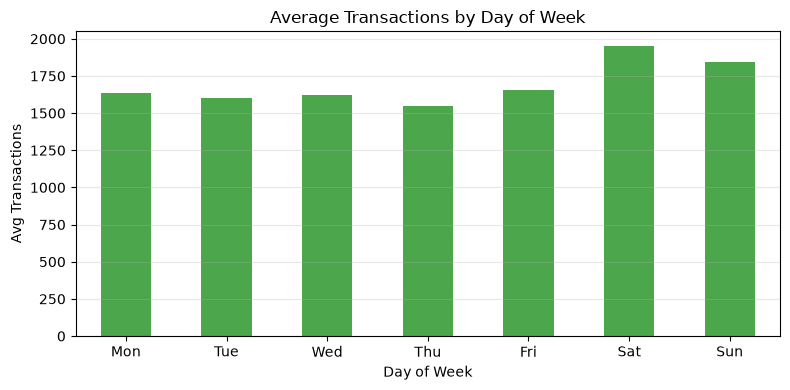

In [16]:
print(transactions.head())

# Average transactions by day of week
transactions['dayofweek'] = transactions['date'].dt.dayofweek
dow_trans = transactions.groupby('dayofweek')['transactions'].mean()

plt.figure(figsize=(8, 4))
dow_trans.plot(kind='bar', color='green', alpha=0.7)
plt.title('Average Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Transactions')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

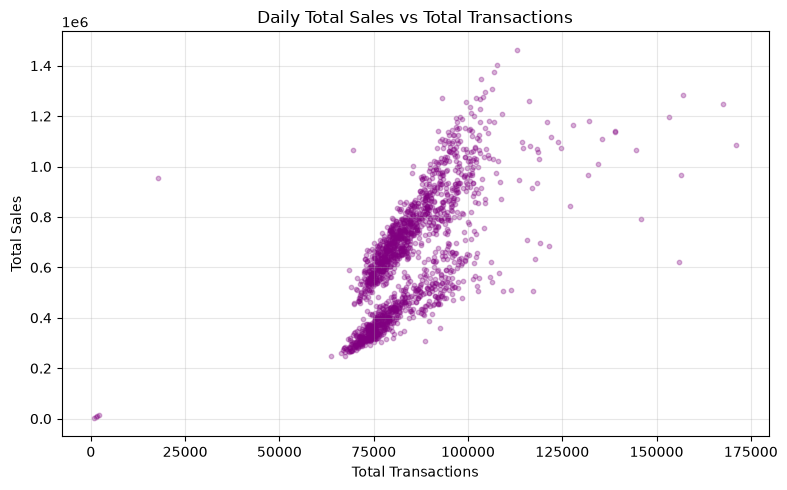

Correlation: 0.677


In [17]:
# Aggregate both to daily level
daily_sales_agg = train.groupby('date')['sales'].sum().reset_index()
daily_trans_agg = transactions.groupby('date')['transactions'].sum().reset_index()

merged = daily_sales_agg.merge(daily_trans_agg, on='date')

plt.figure(figsize=(8, 5))
plt.scatter(merged['transactions'], merged['sales'], alpha=0.3, color='purple', s=10)
plt.title('Daily Total Sales vs Total Transactions')
plt.xlabel('Total Transactions')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation: {merged['transactions'].corr(merged['sales']):.3f}")

In [18]:
print("""
=== EDA SUMMARY ===

Dataset grain: 1 row per date + store + product family
Date range: 2013-01-01 to 2017-08-15
Stores: 54
Product families: 33

Key findings:
- Oil.csv has missing values (weekends/holidays) → need forward fill in dbt
- Sales have strong weekly seasonality (weekends higher)
- Sales have strong yearly seasonality (Dec spike)
- Store type significantly impacts sales volume
- Transactions and sales are highly correlated

Next step: Load all tables into DuckDB (Phase 3)
""")


=== EDA SUMMARY ===

Dataset grain: 1 row per date + store + product family
Date range: 2013-01-01 to 2017-08-15
Stores: 54
Product families: 33

Key findings:
- Oil.csv has missing values (weekends/holidays) → need forward fill in dbt
- Sales have strong weekly seasonality (weekends higher)
- Sales have strong yearly seasonality (Dec spike)
- Store type significantly impacts sales volume
- Transactions and sales are highly correlated

Next step: Load all tables into DuckDB (Phase 3)

